# Advanced Modeling : Ensemble & Hyperparameter Optimization

## Context
This notebook is the fifth and final modeling step in the pipeline for the
[Ames Housing dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques).
It supersedes both `03_Modeling.ipynb` (linear models, best CV RMSE: 0.1190)
and `04_Modeling_Trees.ipynb` (tree-based models + stacking, best CV RMSE:
0.1122) by rebuilding the full pipeline from raw data with four simultaneous
improvements.

## Objectives
1. **Enhanced feature engineering** : interaction terms between the strongest
   predictors, a composite quality index, and KFold target encoding for
   high-cardinality categoricals (replacing one-hot for features like
   Neighborhood where the category count is large and the price gradient is
   strong).
2. **New model families** : LightGBM and CatBoost join the model pool alongside
   XGBoost, sklearn GradientBoosting, and the linear models from previous
   notebooks.
3. **Bayesian hyperparameter tuning** : Optuna with TPE sampler replaces
   RandomizedSearchCV for XGBoost, LightGBM, and CatBoost. Each study runs
   80 to 100 trials with 5-fold inner CV.
4. **Advanced ensemble** : a 7-model stacking ensemble (3 linear + 4 boosting)
   with Ridge meta-learner, complemented by an optimized weighted blend. The
   final submission averages both ensemble strategies.

## Table of Contents

**Part A : Data Preparation**

1. [Imports & Data Loading](#1-imports-data-loading)
2. [Outlier Removal](#2-outlier-removal)
3. [Missing Value Imputation](#3-missing-value-imputation)
4. [Target Transformation](#4-target-transformation)
5. [Feature Creation](#5-feature-creation)
6. [Ordinal Encoding](#6-ordinal-encoding)
7. [Target Encoding (KFold)](#7-target-encoding)
8. [One-Hot Encoding](#8-one-hot-encoding)
9. [Skewness Correction](#9-skewness-correction)
10. [Feature Selection & Train-Test Split](#10-feature-selection)

**Part B : Modeling**

11. [Evaluation Framework](#11-evaluation-framework)
12. [Base Models, Linear](#12-base-models-linear)
13. [XGBoost, Optuna Tuning](#13-xgboost)
14. [LightGBM, Optuna Tuning](#14-lightgbm)
15. [CatBoost, Optuna Tuning](#15-catboost)
16. [GradientBoosting (sklearn)](#16-gbr)
17. [Model Comparison](#17-model-comparison)
18. [Stacking Ensemble](#18-stacking)
19. [Weighted Blending](#19-blending)
20. [Final Ensemble & Submission](#20-final-ensemble)
21. [Residual Analysis](#21-residual-analysis)

## 1. Imports & Data Loading <a id="1-imports-data-loading"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import (
    cross_val_score, cross_val_predict, KFold
)
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNetCV
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.5f}".format)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
np.random.seed(SEED)

In [2]:
train_raw = pd.read_csv("../data/raw/train.csv")
test_raw  = pd.read_csv("../data/raw/test.csv")

target   = train_raw["SalePrice"].copy()
test_ids = test_raw["Id"].copy()

train_raw = train_raw.drop(columns=["SalePrice", "Id"])
test_raw  = test_raw.drop(columns=["Id"])

df = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)
n_train = len(train_raw)

print(f"Train: {train_raw.shape} | Test: {test_raw.shape} | Combined: {df.shape}")
print(f"n_train: {n_train}")

Train: (1460, 79) | Test: (1459, 79) | Combined: (2919, 79)
n_train: 1460


## 2. Outlier Removal <a id="2-outlier-removal"></a>

Seven observations are removed based on two criteria established during EDA and
residual analysis from `04_Modeling_Trees.ipynb`:

1. **GrLivArea > 4000 with SalePrice < $300k** (idx 523, 1298): extremely large
   houses sold far below the trend line, consistent with partial sales or
   damaged properties.
2. **Flagged by 3+ key features** (idx 30, 410, 495, 916, 968): very low
   quality properties (OverallQual 2 to 5) sold at extreme bottom prices
   ($34,900 to $60,000). These observations sit far outside the main
   distribution across GrLivArea, TotalBsmtSF, LotArea, GarageArea, and
   1stFlrSF simultaneously, distorting learned relationships for the vast
   majority of the dataset.

In [3]:
outlier_idx = [30, 410, 495, 523, 916, 968, 1298]

print(f"Outliers identified: {len(outlier_idx)}\n")
print(train_raw.loc[outlier_idx, ["GrLivArea", "OverallQual"]].join(
    target[outlier_idx].rename("SalePrice")
))

df      = df.drop(index=outlier_idx).reset_index(drop=True)
target  = target.drop(index=outlier_idx).reset_index(drop=True)
n_train = n_train - len(outlier_idx)

print(f"\nRows removed: {len(outlier_idx)}")
print(f"df shape:     {df.shape}")
print(f"n_train:      {n_train}")

Outliers identified: 7

      GrLivArea  OverallQual  SalePrice
30         1317            4      40000
410        1276            5      60000
495         720            4      34900
523        4676           10     184750
916         480            2      35311
968         968            3      37900
1298       5642           10     160000

Rows removed: 7
df shape:     (2912, 79)
n_train:      1453


## 3. Missing Value Imputation <a id="3-missing-value-imputation"></a>

Missing values fall into three categories handled in order:

1. **Semantic NaN (categorical)**: features where NaN means "absent" (no pool,
   no garage, no basement). Filled with `"None"`.
2. **Semantic NaN (numerical)**: associated numerical features for absent
   elements (e.g. BsmtFinSF1 when there is no basement). Filled with `0`.
   GarageArea and GarageCars have a small number of true missing values filled
   with the median.
3. **True missing values**: LotFrontage (imputed by Neighborhood median),
   GarageYrBlt (proxied by YearBuilt), and low-frequency categoricals filled
   with their mode.

This is identical to the strategy validated in `02_Features.ipynb`.

In [4]:
#Semantic NaN (categorical) 
semantic_cat = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]
df[semantic_cat] = df[semantic_cat].fillna("None")

#Semantic NaN (numerical)
semantic_num = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea',
]
df[semantic_num] = df[semantic_num].fillna(0)

for feat in ['GarageArea', 'GarageCars']:
    df[feat] = df[feat].fillna(df[feat].median())

#True missing values
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

for feat in ['MSZoning', 'Functional', 'Utilities', 'KitchenQual',
             'Exterior1st', 'Exterior2nd', 'SaleType']:
    df[feat] = df[feat].fillna(df[feat].mode()[0])

print(f"Remaining NaN: {df.isnull().sum().sum()}")

Remaining NaN: 0


## 4. Target Transformation <a id="4-target-transformation"></a>

`SalePrice` follows a right-skewed distribution (skewness ~1.88) that violates
the normality assumption of linear models. Applying `log1p` reduces skewness to
~0.12, producing a near-Gaussian distribution. This also aligns with the Kaggle
evaluation metric (RMSLE), which is equivalent to RMSE on log-transformed
prices.

This is identical to the strategy used in `02_Features.ipynb`.

In [5]:
target_log = np.log1p(target)

print(f"Skewness before: {target.skew():.4f}")
print(f"Skewness after:  {target_log.skew():.4f}")
print(f"target_log shape: {target_log.shape}")

Skewness before: 1.9092
Skewness after:  0.2624
target_log shape: (1453,)


## 5. Feature Creation <a id="5-feature-creation"></a>

Interaction terms capture nonlinear relationships that individual features
cannot express. The key insight is that the effect of surface area on price is
not constant: it depends on quality. A large house with low quality is worth
less than a smaller house with excellent quality. Multiplying OverallQual by
surface features encodes this dependency directly.

Note that multiplicative interactions produce values at a much larger scale
than the original features (e.g. OverallQual 10 × TotalSF 4000 = 40,000).
This is not a problem for tree-based models (XGBoost, LightGBM, CatBoost)
which are scale-invariant, but it would distort linear model coefficients
without proper scaling. The `RobustScaler` applied before all linear models in
Part B (Section 11) handles this.

In [7]:
#Composite features
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = (df['FullBath'] + df['BsmtFullBath'] + 0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath'])
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])
df['HasRemodel'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

#Interaction features
df['Qual_x_TotalSF'] = df['OverallQual'] * df['TotalSF']
df['Qual_x_GrLivArea'] = df['OverallQual'] * df['GrLivArea']
df['Qual_x_HouseAge'] = df['OverallQual'] * df['HouseAge']
df['Garage_x_Cars'] = df['GarageArea'] * df['GarageCars']
df['SF_per_Room'] = df['GrLivArea'] / df['TotRmsAbvGrd'].replace(0, 1)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)

print(f"12 features created | df shape: {df.shape}")
print(f"\n{'Feature':<22} {'Mean':>10} {'Std':>10}")
print("=" * 44)
for feat in ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HasRemodel',
             'HouseAge', 'RemodAge', 'Qual_x_TotalSF', 'Qual_x_GrLivArea',
             'Qual_x_HouseAge', 'Garage_x_Cars', 'SF_per_Room', 'Has2ndFloor']:
    print(f"  {feat:<20} {df[feat].mean():>10.2f} {df[feat].std():>10.2f}")

12 features created | df shape: (2912, 91)

Feature                      Mean        Std
  TotalSF                 2543.97     780.64
  TotalBath                  2.22       0.81
  TotalPorchSF              88.93     107.26
  HasRemodel                 0.46       0.50
  HouseAge                  36.44      30.30
  RemodAge                  23.49      20.86
  Qual_x_TotalSF         16227.57    8211.93
  Qual_x_GrLivArea        9529.65    4880.98
  Qual_x_HouseAge          196.58     164.21
  Garage_x_Cars            981.45     736.67
  SF_per_Room              231.31      45.68
  Has2ndFloor                0.43       0.49


## 6. Ordinal Encoding <a id="6-ordinal-encoding"></a>

Quality features follow a consistent ordinal scale (Ex > Gd > TA > Fa > Po)
confirmed by monotonic price gradients in EDA. These are mapped to integers
to preserve ranking information. Features with their own distinct scale
(BsmtExposure, BsmtFinType, GarageFinish, Fence) receive dedicated mappings.

A composite `QualityIndex` is added by averaging the four most price-correlated
quality features (ExterQual, KitchenQual, BsmtQual, GarageQual). This gives
models a single aggregate quality signal without requiring them to learn the
combination from scratch.

This section is identical to `02_Features.ipynb` except for the QualityIndex.

In [8]:
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC',
]

for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
bsmt_fintype_map  = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
garage_finish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}

df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exposure_map)
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fintype_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fintype_map)
df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map)
df['Fence'] = df['Fence'].map(fence_map)

# NEW: composite quality index
df['QualityIndex'] = (df['ExterQual'] + df['KitchenQual'] + df['BsmtQual'] + df['GarageQual']) / 4

all_ordinal = ordinal_cols + [
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence'
]

print(f"{len(all_ordinal)} features ordinally encoded")
print(f"QualityIndex: mean={df['QualityIndex'].mean():.2f}, std={df['QualityIndex'].std():.2f}")
print(f"Unmapped NaN check: {df[all_ordinal].isnull().sum().sum()}")

15 features ordinally encoded
QualityIndex: mean=3.30, std=0.53
Unmapped NaN check: 0


## 7. Target Encoding (KFold) <a id="7-target-encoding"></a>

Target encoding replaces each category level with the mean target value for
that level. This is particularly effective for high-cardinality features like
Neighborhood (25 levels) or MSSubClass (16 levels), where one-hot encoding
creates many sparse columns that dilute signal and increase dimensionality.

### Leakage prevention

Naive target encoding (computing the mean directly on the full training set)
leaks target information into the features, causing overfitting. To prevent
this, encoding is computed with a 5-fold scheme: for each fold, the target
mean is calculated on the out-of-fold data only. Test set categories use the
global train mean per level.

### Smoothing

A smoothing parameter blends the category mean with the global mean. This
regularizes rare categories where the per-category mean is unreliable due to
small sample size. The formula is:

encoded = (count × category_mean + smoothing × global_mean) / (count + smoothing)

With `smoothing=10`, a category with only 2 observations gets a value much
closer to the global mean, while a category with 200 observations is barely
affected.

### Features selected for target encoding

Only features with high cardinality or strong price gradients identified in
EDA are target-encoded. The remaining nominal features stay one-hot encoded
in Section 8.

In [9]:
te_cols = ['Neighborhood', 'MSSubClass', 'Condition1', 'Exterior1st',
           'Exterior2nd', 'SaleType', 'SaleCondition']

SMOOTHING = 10

def target_encode_kfold(df, col, target, n_train, n_splits=5, smoothing=SMOOTHING):
    """KFold target encoding with smoothing. Returns the encoded column."""
    encoded = pd.Series(np.nan, index=df.index, dtype=float)
    global_mean = target.mean()

    train_df = df.iloc[:n_train]
    kf_te = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for tr_idx, val_idx in kf_te.split(train_df):
        tr_target = target.iloc[tr_idx]
        means = train_df.iloc[tr_idx].groupby(col).apply(
            lambda x: (tr_target.loc[x.index].sum() + smoothing * global_mean)
                      / (len(x) + smoothing)
        )
        encoded.iloc[val_idx] = train_df.iloc[val_idx][col].map(means)

    # Fill any remaining NaN in train (rare categories absent from a fold)
    encoded.iloc[:n_train] = encoded.iloc[:n_train].fillna(global_mean)

    # Test set: use full train means with smoothing
    full_means = train_df.groupby(col).apply(
        lambda x: (target.loc[x.index].sum() + smoothing * global_mean)
                  / (len(x) + smoothing)
    )
    encoded.iloc[n_train:] = df.iloc[n_train:][col].map(full_means).fillna(global_mean)

    return encoded

for col in te_cols:
    df[f'{col}_TE'] = target_encode_kfold(df, col, target_log, n_train)
    nunique = df[col].nunique()
    te_std = df[f'{col}_TE'].std()
    print(f"  {col:<18} -> {col}_TE  (nunique={nunique}, std={te_std:.4f})")

print(f"\n{len(te_cols)} target-encoded features created")
print(f"NaN check: {df[[f'{c}_TE' for c in te_cols]].isnull().sum().sum()}")

  Neighborhood       -> Neighborhood_TE  (nunique=25, std=0.2462)
  MSSubClass         -> MSSubClass_TE  (nunique=16, std=0.1984)
  Condition1         -> Condition1_TE  (nunique=9, std=0.0642)
  Exterior1st        -> Exterior1st_TE  (nunique=15, std=0.1513)
  Exterior2nd        -> Exterior2nd_TE  (nunique=16, std=0.1488)
  SaleType           -> SaleType_TE  (nunique=9, std=0.1213)
  SaleCondition      -> SaleCondition_TE  (nunique=6, std=0.1233)

7 target-encoded features created
NaN check: 0


## 8. One-Hot Encoding <a id="8-one-hot-encoding"></a>

The 7 features that were target-encoded in Section 7 are dropped (their `_TE`
versions replace them). All remaining nominal features are one-hot encoded with
`drop_first=True` to avoid perfect multicollinearity.

Compared to `02_Features.ipynb` where all 28 nominal features were one-hot
encoded (producing 216 columns), this hybrid approach reduces dimensionality
by replacing the highest-cardinality features with single continuous columns.

In [10]:
# Drop original columns that were target-encoded
df = df.drop(columns=te_cols)

# One-hot encode remaining nominal features
nominal_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"{len(nominal_cols)} nominal features to one-hot encode")
print(f"(vs 28 in 02_Features.ipynb, 7 replaced by target encoding)\n")

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df.shape}")

22 nominal features to one-hot encode
(vs 28 in 02_Features.ipynb, 7 replaced by target encoding)

Shape after encoding: (2912, 155)


## 9. Skewness Correction <a id="9-skewness-correction"></a>

Highly skewed numerical features distort coefficient estimation in linear
models. Features with |skewness| > 0.75 are transformed with `log1p` to
reduce asymmetry. Only continuous numerical features are considered (ordinal
encoded and binary features are excluded).

In [11]:
all_ordinal_set = set(all_ordinal + ['HasRemodel', 'Has2ndFloor'])
numerical_feats = df.select_dtypes(include=[np.number]).columns.tolist()
continuous = [c for c in numerical_feats
              if c not in all_ordinal_set and df[c].nunique() > 15]

skewness = df[continuous].skew()
high_skew = skewness[skewness.abs() > 0.75]

skew_before = df[high_skew.index].skew()
df_transformed = df[high_skew.index].apply(np.log1p)
skew_after = df_transformed.skew()

improved = skew_after.abs() < skew_before.abs()
apply_cols = improved[improved].index.tolist()
skip_cols  = improved[~improved].index.tolist()

df[apply_cols] = df_transformed[apply_cols]

print(f"Skewness corrected: {len(apply_cols)} / {len(high_skew)} features")
print(f"Skipped (log1p worsened): {len(skip_cols)}")
if skip_cols:
    for c in skip_cols:
        print(f"  {c:<22} before={skew_before[c]:.4f}  after={skew_after[c]:.4f}")

Skewness corrected: 22 / 26 features
Skipped (log1p worsened): 4
  BsmtUnfSF              before=0.9205  after=-2.1530
  Qual_x_HouseAge        before=1.0410  after=-1.3947
  Garage_x_Cars          before=1.4203  after=-2.8511
  Condition1_TE          before=-2.5314  after=-2.5444


## 10. Feature Selection & Train-Test Split <a id="10-feature-selection"></a>

Features are removed based on two criteria established during EDA: redundancy
with composite features created in Section 5, and multicollinearity identified
in the correlation analysis. Each removal is justified by a specific diagnostic
from `01_EDA.ipynb`.

In [12]:
drop_cols = [
    'GarageArea', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF',
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
    'GarageYrBlt', 'YearBuilt', 'YearRemodAdd',
]
drop_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=drop_cols)

X_train = df.iloc[:n_train].reset_index(drop=True)
X_test  = df.iloc[n_train:].reset_index(drop=True)
y_train = target_log.reset_index(drop=True)

print(f"{len(drop_cols)} features dropped")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"NaN: train={X_train.isnull().sum().sum()}, test={X_test.isnull().sum().sum()}")

11 features dropped
X_train: (1453, 144)
X_test:  (1459, 144)
y_train: (1453,)
NaN: train=0, test=0


## 11. Evaluation Framework <a id="11-evaluation-framework"></a>

All models are evaluated with 10-fold cross-validation (up from 5-fold in
`03_Modeling.ipynb` and `04_Modeling_Trees.ipynb`) for more stable RMSE
estimates. The scoring metric is RMSE in log space, which is equivalent to the
Kaggle leaderboard metric (RMSLE on original prices).

Linear models require feature scaling because they are sensitive to the
magnitude of input values. A `RobustScaler` is used instead of the
`StandardScaler` from `03_Modeling.ipynb`: it scales using median and IQR
rather than mean and standard deviation, making it more resistant to the
residual outliers that remain after the cleaning in Section 2.

Tree-based models are scale-invariant and do not need a scaler.

In [13]:
N_FOLDS = 10
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def evaluate(model, X, y, label="Model", use_scaler=False):
    """Evaluate with K-Fold CV. Returns per-fold RMSE array."""
    if use_scaler:
        pipe = Pipeline([("scaler", RobustScaler()), ("model", model)])
    else:
        pipe = model

    scores = cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_squared_error",
                             n_jobs=-1)
    rmse = np.sqrt(-scores)
    print(f"  {label:<28} RMSE: {rmse.mean():.5f} (+/- {rmse.std():.5f})")
    return rmse

all_results = {}

print(f"Evaluation framework ready: {N_FOLDS}-fold CV, SEED={SEED}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

Evaluation framework ready: 10-fold CV, SEED=42
X_train: (1453, 144), y_train: (1453,)


## 12. Base Models, Linear <a id="12-base-models-linear"></a>

Ridge, Lasso, and ElasticNet with built-in cross-validated alpha selection.
These models require scaling (handled by the `use_scaler=True` flag) and serve
as the linear component of the final ensemble, capturing additive relationships
that tree-based models may underfit.

Compared to `03_Modeling.ipynb`, two changes are made:
1. The alpha search grid is wider and denser (200 points instead of 100)
2. `RobustScaler` replaces `StandardScaler` for better outlier resistance

The benchmark from `03_Modeling.ipynb` is Lasso at 0.1190 (5-fold CV). Note
that scores are not directly comparable due to the switch from 5-fold to
10-fold CV and the different feature set, but the direction of improvement is
meaningful.

In [14]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 200), cv=5)
all_results["Ridge"] = evaluate(ridge, X_train, y_train, "Ridge", use_scaler=True)

lasso = LassoCV(alphas=np.logspace(-5, 0, 200), cv=5, max_iter=20000,
                random_state=SEED)
all_results["Lasso"] = evaluate(lasso, X_train, y_train, "Lasso", use_scaler=True)

enet = ElasticNetCV(
    alphas=np.logspace(-5, 0, 100),
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
    cv=5, max_iter=20000, random_state=SEED,
)
all_results["ElasticNet"] = evaluate(enet, X_train, y_train, "ElasticNet",
                                     use_scaler=True)

  Ridge                        RMSE: 0.10958 (+/- 0.01358)
  Lasso                        RMSE: 0.11148 (+/- 0.01223)
  ElasticNet                   RMSE: 0.11106 (+/- 0.01203)


## 13. XGBoost, Optuna Tuning <a id="13-xgboost"></a>

XGBoost is tuned with Optuna's TPE (Tree-structured Parzen Estimator) sampler.
Unlike `RandomizedSearchCV` used in `04_Modeling_Trees.ipynb` (which samples
hyperparameters uniformly at random), TPE builds a probabilistic model of the
objective function and concentrates trials in the most promising regions of the
search space. This typically finds better configurations in fewer trials.

The study runs 100 trials with 5-fold inner CV. The best parameters are then
evaluated with the full 10-fold outer CV for a fair comparison with other
models.

In [ ]:
def optuna_cv_score(model, X, y, n_splits=5):
    """Quick 5-fold CV RMSE for Optuna objective."""
    kf_inner = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, X, y, cv=kf_inner, scoring="neg_mean_squared_error", n_jobs=-1)
    return np.sqrt(-scores).mean()

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 1000, 5000, step=500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": 0,
    }
    model = XGBRegressor(**params)
    return optuna_cv_score(model, X_train, y_train)

xgb_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest XGBoost RMSE (5-fold inner CV): {xgb_study.best_value:.5f}")
print(f"Best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k:<20} {v}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best XGBoost RMSE (5-fold inner CV): 0.10973
Best params:
  n_estimators         3500
  learning_rate        0.02030462506841882
  max_depth            4
  subsample            0.6075866044384578
  colsample_bytree     0.6720227002081556
  reg_alpha            0.032021476652048235
  reg_lambda           1.2881325422998626
  min_child_weight     4
  gamma                0.014433453009371737


In [16]:
xgb_best = XGBRegressor(**xgb_study.best_params, random_state=SEED,
                        n_jobs=-1, verbosity=0)
all_results["XGBoost"] = evaluate(xgb_best, X_train, y_train, "XGBoost (Optuna)")

  XGBoost (Optuna)             RMSE: 0.10855 (+/- 0.01450)


## 14. LightGBM, Optuna Tuning <a id="14-lightgbm"></a>

LightGBM uses a histogram-based algorithm that bins continuous features into
discrete buckets, making tree construction significantly faster than XGBoost's
exact split approach. It also supports leaf-wise tree growth (vs level-wise for
XGBoost), which can produce deeper, more complex trees with fewer splits.

The `num_leaves` parameter controls tree complexity directly (instead of
`max_depth` alone) and is a key hyperparameter specific to LightGBM.

In [17]:
def lgbm_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 1000, 5000, step=500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
    }
    model = LGBMRegressor(**params)
    return optuna_cv_score(model, X_train, y_train)

lgbm_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgbm_study.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest LightGBM RMSE (5-fold inner CV): {lgbm_study.best_value:.5f}")
print(f"Best params:")
for k, v in lgbm_study.best_params.items():
    print(f"  {k:<20} {v}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best LightGBM RMSE (5-fold inner CV): 0.11110
Best params:
  n_estimators         1500
  learning_rate        0.026710165554841295
  max_depth            3
  num_leaves           107
  subsample            0.712614767500716
  colsample_bytree     0.5206965710608873
  reg_alpha            0.39541955371331444
  reg_lambda           0.45492334746052865
  min_child_samples    5


In [20]:
lgbm_best = LGBMRegressor(**lgbm_study.best_params, random_state=SEED, n_jobs=-1, verbosity=-1)
all_results["LightGBM"] = evaluate(lgbm_best, X_train, y_train, "LightGBM (Optuna)")

  LightGBM (Optuna)            RMSE: 0.11001 (+/- 0.01443)


## 15. CatBoost, Optuna Tuning <a id="15-catboost"></a>

CatBoost uses ordered boosting, a permutation-based approach that reduces
prediction shift (a form of target leakage in gradient boosting). It also
handles categorical features natively, though in this notebook all categoricals
have already been encoded in Part A.

The study runs 80 trials (fewer than XGBoost and LightGBM because CatBoost
trains more slowly per trial).

In [19]:
def catboost_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 1000, 5000, step=500),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth":               trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 5),
        "random_strength":     trial.suggest_float("random_strength", 0, 5),
        "border_count":        trial.suggest_int("border_count", 32, 255),
        "random_seed": SEED,
        "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    return optuna_cv_score(model, X_train, y_train)

cat_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
cat_study.optimize(catboost_objective, n_trials=80, show_progress_bar=True)

print(f"\nBest CatBoost RMSE (5-fold inner CV): {cat_study.best_value:.5f}")
print(f"Best params:")
for k, v in cat_study.best_params.items():
    print(f"  {k:<24} {v}")

  0%|          | 0/80 [00:00<?, ?it/s]


Best CatBoost RMSE (5-fold inner CV): 0.10735
Best params:
  iterations               5000
  learning_rate            0.010631481177602098
  depth                    5
  l2_leaf_reg              0.328691637063735
  bagging_temperature      3.1060921870999456
  random_strength          2.139847679969409
  border_count             152


In [21]:
cat_best = CatBoostRegressor(**cat_study.best_params, random_seed=SEED, verbose=0)
all_results["CatBoost"] = evaluate(cat_best, X_train, y_train, "CatBoost (Optuna)")

  CatBoost (Optuna)            RMSE: 0.10625 (+/- 0.01486)


## 16. GradientBoosting (sklearn) <a id="16-gbr"></a>

Scikit-learn's GradientBoostingRegressor uses a different implementation than
XGBoost, LightGBM, and CatBoost. It does not support histogram binning or
advanced regularization, but its different internal mechanics (exact greedy
splits, Friedman MSE criterion) produce slightly different error patterns,
which adds diversity to the final ensemble.

Hyperparameters are set manually based on standard best practices rather than
Optuna-tuned, to keep computation time reasonable while still contributing a
distinct model to the stack.

In [22]:
gb = GradientBoostingRegressor(
    n_estimators=3000, learning_rate=0.03, max_depth=4,
    min_samples_leaf=5, subsample=0.8, max_features=0.6,
    random_state=SEED,
)
all_results["GBR"] = evaluate(gb, X_train, y_train, "GBR (sklearn)")

  GBR (sklearn)                RMSE: 0.11195 (+/- 0.01346)


## 17. Model Comparison <a id="17-model-comparison"></a>

Side-by-side comparison of all individual models before ensembling. The chart
shows both mean RMSE and fold-to-fold stability (error bars). The two
horizontal references mark the benchmarks from previous notebooks: Lasso
(0.1190 from `03_Modeling.ipynb`) and Stacking (0.1122 from
`04_Modeling_Trees.ipynb`).

In [23]:
comparison = pd.DataFrame({
    name: {
        "Mean RMSE": s.mean(),
        "Std": s.std(),
        "Min": s.min(),
        "Max": s.max(),
    }
    for name, s in all_results.items()
}).T.sort_values("Mean RMSE")

comparison

,Mean RMSE,Std,Min,Max
CatBoost,0.10625,0.01486,0.07804,0.13312
XGBoost,0.10855,0.01450,0.08134,0.13254
Ridge,0.10958,0.01358,0.08225,0.13598
LightGBM,0.11001,0.01443,0.08368,0.13429
ElasticNet,0.11106,0.01203,0.09000,0.13618
Lasso,0.11148,0.01223,0.08995,0.13615
GBR,0.11195,0.01346,0.08697,0.13632


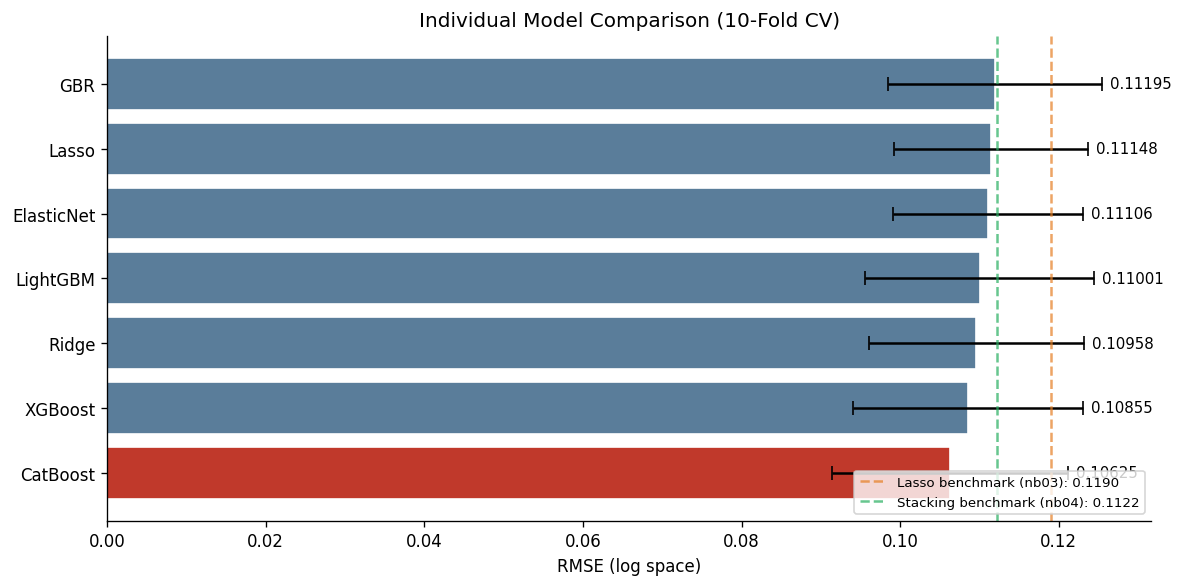

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

names = comparison.index.tolist()
means = comparison["Mean RMSE"].values
stds  = comparison["Std"].values

colors = ["#c0392b" if m == means.min() else "#5a7d9a" for m in means]

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor="white", capsize=4)

ax.axvline(x=0.1190, color="#e67e22", linestyle="--", alpha=0.7,
           label="Lasso benchmark (nb03): 0.1190")
ax.axvline(x=0.1122, color="#27ae60", linestyle="--", alpha=0.7,
           label="Stacking benchmark (nb04): 0.1122")

ax.set_xlabel("RMSE (log space)")
ax.set_title("Individual Model Comparison (10-Fold CV)")
ax.legend(loc="lower right", fontsize=8)

for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.001, i, f"{m:.5f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 18. Stacking Ensemble <a id="18-stacking"></a>

The stacking ensemble combines all 7 base models through a Ridge meta-learner.
The key principle is diversity: linear models capture additive effects, each
gradient boosting variant brings slightly different inductive biases, and the
meta-learner learns the optimal weight for each base model's predictions via
cross-validated training.

Architecture:
- Linear layer: Ridge, Lasso, ElasticNet (all scaled with RobustScaler)
- Tree layer: XGBoost, LightGBM, CatBoost, GBR (no scaling needed)
- Meta-learner: RidgeCV (alpha tuned by internal CV)

Compared to `04_Modeling_Trees.ipynb` which stacked only 2 models (Lasso +
XGBoost), this ensemble leverages 7 diverse base learners.

In [25]:
lasso_pipe = make_pipeline(
    RobustScaler(),
    LassoCV(alphas=np.logspace(-5, 0, 200), cv=5, max_iter=20000,
            random_state=SEED)
)

enet_pipe = make_pipeline(
    RobustScaler(),
    ElasticNetCV(alphas=np.logspace(-5, 0, 100),
                 l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
                 cv=5, max_iter=20000, random_state=SEED)
)

ridge_pipe = make_pipeline(
    RobustScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 200), cv=5)
)

stack = StackingRegressor(
    estimators=[
        ("ridge",    ridge_pipe),
        ("lasso",    lasso_pipe),
        ("enet",     enet_pipe),
        ("xgb",      XGBRegressor(**xgb_study.best_params, random_state=SEED,
                                   n_jobs=-1, verbosity=0)),
        ("lgbm",     LGBMRegressor(**lgbm_study.best_params, random_state=SEED,
                                    n_jobs=-1, verbosity=-1)),
        ("catboost", CatBoostRegressor(**cat_study.best_params, random_seed=SEED,
                                       verbose=0)),
        ("gbr",      GradientBoostingRegressor(
                         n_estimators=3000, learning_rate=0.03, max_depth=4,
                         min_samples_leaf=5, subsample=0.8, max_features=0.6,
                         random_state=SEED)),
    ],
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 100)),
    cv=5,
    n_jobs=-1,
)

all_results["Stacking (7)"] = evaluate(stack, X_train, y_train, "Stacking (7 models)")

  Stacking (7 models)          RMSE: 0.10430 (+/- 0.01353)


## 19. Weighted Blending <a id="19-blending"></a>

As an alternative to stacking, weighted blending averages out-of-fold
predictions with weights optimized to minimize RMSE. The two ensemble
strategies (stacking and blending) make slightly different errors because
they combine models differently: stacking trains a meta-learner on
out-of-fold predictions, while blending directly optimizes a weighted average.

The weight optimization uses `scipy.optimize.minimize` with the constraint
that weights sum to 1 and remain non-negative.

In [26]:
models_for_blend = {
    "Ridge":    make_pipeline(RobustScaler(),
                              RidgeCV(alphas=np.logspace(-3, 3, 200), cv=5)),
    "Lasso":    make_pipeline(RobustScaler(),
                              LassoCV(alphas=np.logspace(-5, 0, 200), cv=5,
                                      max_iter=20000, random_state=SEED)),
    "ENet":     make_pipeline(RobustScaler(),
                              ElasticNetCV(alphas=np.logspace(-5, 0, 100),
                                           l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
                                           cv=5, max_iter=20000, random_state=SEED)),
    "XGB":      XGBRegressor(**xgb_study.best_params, random_state=SEED,
                             n_jobs=-1, verbosity=0),
    "LGBM":     LGBMRegressor(**lgbm_study.best_params, random_state=SEED,
                              n_jobs=-1, verbosity=-1),
    "CatBoost": CatBoostRegressor(**cat_study.best_params, random_seed=SEED,
                                  verbose=0),
    "GBR":      GradientBoostingRegressor(n_estimators=3000, learning_rate=0.03,
                                          max_depth=4, min_samples_leaf=5,
                                          subsample=0.8, max_features=0.6,
                                          random_state=SEED),
}

oof_preds = {}
for name, model in models_for_blend.items():
    oof = cross_val_predict(model, X_train, y_train, cv=kf, n_jobs=-1)
    oof_preds[name] = oof
    rmse = np.sqrt(np.mean((y_train - oof) ** 2))
    print(f"  {name:<12} OOF RMSE: {rmse:.5f}")

  Ridge        OOF RMSE: 0.11041
  Lasso        OOF RMSE: 0.11213
  ENet         OOF RMSE: 0.11170
  XGB          OOF RMSE: 0.10950
  LGBM         OOF RMSE: 0.11094
  CatBoost     OOF RMSE: 0.10727
  GBR          OOF RMSE: 0.11274


In [27]:
oof_matrix = np.column_stack(list(oof_preds.values()))
model_names = list(oof_preds.keys())

def blend_rmse(weights):
    blended = oof_matrix @ weights
    return np.sqrt(np.mean((y_train.values - blended) ** 2))

n_models = len(model_names)
initial_weights = np.ones(n_models) / n_models

constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
bounds = [(0, 1)] * n_models

result = minimize(blend_rmse, initial_weights, method="SLSQP",
                  bounds=bounds, constraints=constraints)

optimal_weights = result.x

print(f"\nOptimal weights (RMSE={result.fun:.5f}):\n")
for name, w in zip(model_names, optimal_weights):
    bar = "█" * int(w * 50)
    print(f"  {name:<12} {w:.4f}  {bar}")


Optimal weights (RMSE=0.10468):

  Ridge        0.3752  ██████████████████
  Lasso        0.0000  
  ENet         0.0000  
  XGB          0.1168  █████
  LGBM         0.0840  ████
  CatBoost     0.4240  █████████████████████
  GBR          0.0000  


## 20. Final Ensemble & Submission <a id="20-final-ensemble"></a>

The final prediction averages the stacking and weighted blending predictions.
This simple combination often outperforms either method alone because the two
ensemble strategies make slightly different errors: stacking uses a trained
meta-learner while blending uses directly optimized weights.

Both models are retrained on the full training set before generating test
predictions.

In [28]:
# Fit stacking on full train
stack.fit(X_train, y_train)
pred_stack = stack.predict(X_test)

# Fit all blend models on full train and predict
blend_preds_test = []
for name, model in models_for_blend.items():
    model.fit(X_train, y_train)
    blend_preds_test.append(model.predict(X_test))
    print(f"  {name:<12} fitted on full train")

blend_matrix_test = np.column_stack(blend_preds_test)
pred_blend = blend_matrix_test @ optimal_weights

# Final prediction: average of stacking and blending
pred_final = 0.5 * pred_stack + 0.5 * pred_blend

# Convert back to original scale
prices_stack = np.expm1(pred_stack)
prices_blend = np.expm1(pred_blend)
prices_final = np.expm1(pred_final)

print(f"\nPrice range (stacking):  ${prices_stack.min():>10,.0f}  to  ${prices_stack.max():>10,.0f}")
print(f"Price range (blending):  ${prices_blend.min():>10,.0f}  to  ${prices_blend.max():>10,.0f}")
print(f"Price range (final):     ${prices_final.min():>10,.0f}  to  ${prices_final.max():>10,.0f}")

  Ridge        fitted on full train
  Lasso        fitted on full train
  ENet         fitted on full train
  XGB          fitted on full train
  LGBM         fitted on full train
  CatBoost     fitted on full train
  GBR          fitted on full train

Price range (stacking):  $    54,677  to  $   705,712
Price range (blending):  $    55,213  to  $   680,306
Price range (final):     $    54,944  to  $   692,893


In [29]:
import os

os.makedirs("../submissions", exist_ok=True)

for label, prices in [("stacking", prices_stack),
                      ("blending", prices_blend),
                      ("final", prices_final)]:
    sub = pd.DataFrame({"Id": test_ids, "SalePrice": prices})
    path = f"../submissions/submission_{label}.csv"
    sub.to_csv(path, index=False)
    print(f"Saved {path} | shape: {sub.shape}")

Saved ../submissions/submission_stacking.csv | shape: (1459, 2)
Saved ../submissions/submission_blending.csv | shape: (1459, 2)
Saved ../submissions/submission_final.csv | shape: (1459, 2)


## 21. Residual Analysis <a id="21-residual-analysis"></a>

Diagnostic plots for the best ensemble (Stacking). The model was already fitted
on the full training set in Section 20, so we use those in-sample predictions
to analyze remaining error patterns.

This analysis is compared to the stacking residuals from `04_Modeling_Trees.ipynb`
(std=0.0784, skew=-1.1684) to quantify the improvement.

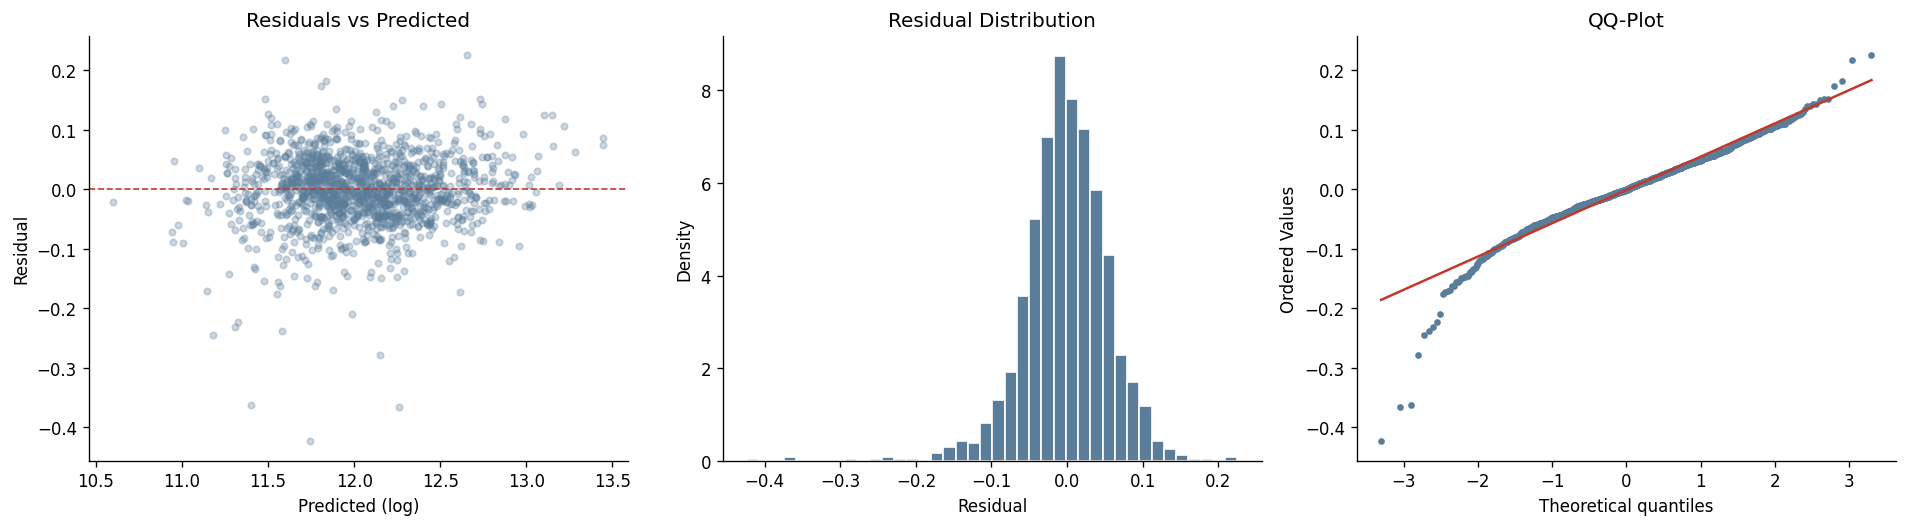

Residuals: mean=-0.000897, std=0.0573, skew=-0.8973

Comparison with 04_Modeling_Trees.ipynb stacking:
  Residual std:  0.0784 -> 0.0573
  Residual skew: -1.1684 -> -0.8973


In [30]:
y_pred_log = stack.predict(X_train)
residuals = y_train - y_pred_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred_log, residuals, alpha=0.3, s=15, color="#5a7d9a")
axes[0].axhline(y=0, color="#c0392b", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted (log)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

# 2. Residual Distribution
axes[1].hist(residuals, bins=40, color="#5a7d9a", edgecolor="white", density=True)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual Distribution")

# 3. QQ-Plot
stats.probplot(residuals, plot=axes[2])
axes[2].set_title("QQ-Plot")
axes[2].get_lines()[0].set(color="#5a7d9a", markersize=3)
axes[2].get_lines()[1].set(color="#c0392b")

plt.tight_layout()
plt.show()

print(f"Residuals: mean={residuals.mean():.6f}, std={residuals.std():.4f}, "
      f"skew={residuals.skew():.4f}")
print(f"\nComparison with 04_Modeling_Trees.ipynb stacking:")
print(f"  Residual std:  0.0784 -> {residuals.std():.4f}")
print(f"  Residual skew: -1.1684 -> {residuals.skew():.4f}")

## Summary

**Part A: Feature Engineering improvements over `02_Features.ipynb`**
- 5 additional outliers removed (total: 7, based on multi-feature residual analysis)
- 6 interaction features capturing nonlinear relationships (quality × size, quality × age)
- 1 composite quality index (QualityIndex)
- KFold target encoding on 7 high-cardinality categoricals, reducing dimensionality
  from 205 to 144 features

**Part B: Modeling improvements over `03_Modeling.ipynb` and `04_Modeling_Trees.ipynb`**
- 2 new model families: LightGBM and CatBoost
- Bayesian hyperparameter tuning (Optuna TPE) replaces RandomizedSearchCV
- 10-fold CV replaces 5-fold for more stable estimates
- 7-model stacking ensemble with Ridge meta-learner
- Optimized weighted blending as complementary ensemble strategy
- Final prediction averages stacking and blending outputs

**Results progression:**

| Notebook | Best Model | RMSE |
|---|---|---|
| 03_Modeling | Lasso | 0.1190 |
| 04_Modeling_Trees | Stacking (Lasso + XGBoost) | 0.1122 |
| 05_Advanced_Modeling | Stacking (7 models) | 0.1043 |